In [4]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import integrate

%matplotlib inline
%precision %g

'%g'

v [$c$] \
$\rho$ [g/cm$^3$] \
L [erg/s]


In [8]:
outflows = {
    'pre': {
        'disk': {
            'v': 0.06,
            'rho': 2.4e-12,
            'L': 4e42
        },
        'jet': {
            'v': 0.5,
            'rho': 4.8e-13,
            'L': 1e43
        }
    },
    'post': {
        'disk': {
            'v': 0.1,
            'rho': 1.5e-12,
            'L': 6.9e42
        },
        'jet': {
            'v': 0.98,
            'rho': 1e-12,
            'L': 4e43
        }
    }
}

## head velocity (eq 2 and 3 [here](https://iopscience.iop.org/article/10.1088/0004-637X/740/2/100/pdf))
Subindices $j, h, c, a$ designate quantities related to the jet, the jet’s head, the cocoon, and the ambient medium, respectively. Everything given in cgs units except $\Sigma_j$, which has $[r_g]$.

The head velocity is
$$
\beta_h = \frac{\beta_j}{1+\tilde{L}^{-1/2}}
$$
$$
\tilde{L} \equiv \frac{\rho_j h_j \Gamma^2_j}{\rho_a} \simeq \frac{L_j}{\Sigma_j \rho_a c^3}
$$
is the jet's breakout luminosity. We have the jet's Lorentz factor
$$
\Gamma_j = \frac{1}{\sqrt{1-\beta_j^2}}
$$
dimensionless specific enthalpy
$$
h_j = 1 + 4P_j/\rho_j c^2
$$
and pressure
$$
P_j = \beta_j^2 \rho_a c^2
$$
$$
\Rightarrow h_j = 1 + 4\beta_j^2 \rho_a / \rho_j
$$
and therefore
$$
\tilde{L} = \frac{1}{1-\beta_j^2}\left(\frac{\rho_j}{\rho_a} + 4\beta_j^2 \right)
$$
The breakout time is
$$
t_{bo} \simeq \int_{r_{in}}^{r_{out}} \frac{dr}{\beta_h}
$$
## assume power law for ISM
$$\rho_{a} = \rho_0 \left(\frac{r}{r_0}\right)^{-\alpha}$$
$\alpha=0.5$ for nuclear ISM \
let $r_0 \sim 50 r_g = r_1$ corresponding to the cavity size from Fig. 5 below, then $\rho_0 \sim 50\rho_0 = \rho_1$ from the density around the cavity in the fiducial simulation in Fig. 3 below
$$\Rightarrow \rho_{a} = 50\rho_0 \left(\frac{r}{50r_g}\right)^{-0.5} = \rho_1 \left(\frac{r}{r_1}\right)^{-0.5}$$
## jet cross sectiong $\Sigma_j$ from Fig.5 [here](https://iopscience.iop.org/article/10.3847/2041-8213/ad9eb5)
<img src="./jet_cross_section.png" alt="cross section" width="40%"/>

## IGM density from Fig. 3
<img src="./ism_density.png" width="90%"/>


$10^6 M_\odot$ for total binary mass

In [9]:
G = 6.674e-8 # cgs units
c = 3e10 # [cm/s]
M_sun = 1.989e33 # [g]
r_g = G* 10**6 * M_sun / c**2
r_g

1.47495e+11

assume jet radius of $\sim50 r_g$ from Fig. 5

In [10]:
sigma = np.pi * (50*r_g)**2
sigma

1.70863e+26

$\rho_0$ set to unity in the [same paper](https://iopscience.iop.org/article/10.3847/2041-8213/ad9eb5)

In [11]:
rho_0 = 10e-23
rho_1 = 50 * rho_0
r_1 = 50 * r_g

In [72]:
def breakout_luminosity(beta, rho_j, rho_a):
    return 1 / (1-beta**2) * (rho_j/rho_a + 4*beta**2)

luminosities = {'pre': {}, 'post': {}}

In [73]:
def integrand(r, merger):
    beta = outflows[merger]['jet']['v']
    # L = outflows[merger]['jet']['L']
    rho_j = outflows[merger]['jet']['v']
    rho_a = rho_1 * (r/r_1)**(-0.5)
    L_tilde = breakout_luminosity(beta, rho_j, rho_a)
    luminosities[merger][r] = L_tilde
    beta_h = beta / (1 + L_tilde**(-1/2))
    v_h = beta_h * c
    return 1 / v_h

parsec

In [74]:
pc = 3.0857e18 # [cm]
Gyr = 3.154e7 # [s]

# Plotting Behavior on the Parsec Scale

In [75]:
r_min = 50 * r_g
r_max_log = 10 * pc
r_maxes_log = np.logspace(np.log10(r_min), np.log10(r_max_log), 500)

t_bo_pre_log = np.array([integrate.quad(integrand, r_min, r, args=('pre'))[0] for r in r_maxes_log])
t_bo_pre_log /= Gyr # convert from s to Gyr

t_bo_post_log = np.array([integrate.quad(integrand, r_min, r, args=('post'))[0] for r in r_maxes_log])
t_bo_post_log /= Gyr # convert from s to Gyr

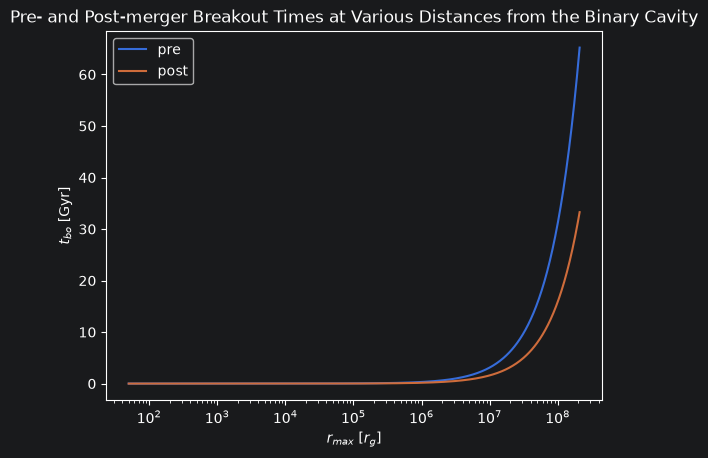

In [76]:
plt.plot(r_maxes_log / r_g, t_bo_pre_log, label='pre')
plt.plot(r_maxes_log / r_g, t_bo_post_log, label='post')
plt.xscale('log')
plt.xlabel(r'$r_{max}$ $[r_g]$')
plt.ylabel(r'$t_{bo}$ [Gyr]')
plt.title('Pre- and Post-merger Breakout Times at Various Distances from the Binary Cavity')
plt.legend()
plt.show()

# Plotting Behavior within ~100s $r_g$

$r_{max} taken from the bottom right panel of Fig 2 in the [paper](https://iopscience.iop.org/article/10.3847/2041-8213/ad9eb5)

In [77]:
r_min = 50 * r_g
r_max = 500 * r_g
r_maxes = np.arange(r_min, r_max, r_g)

t_bo_pre = np.array([integrate.quad(integrand, r_min, r, args=('pre'))[0] for r in r_maxes])
# t_bo_pre /= Gyr # convert from s to Gyr

t_bo_post = np.array([integrate.quad(integrand, r_min, r, args=('post'))[0] for r in r_maxes])
# t_bo_post /= Gyr # convert from s to Gyr

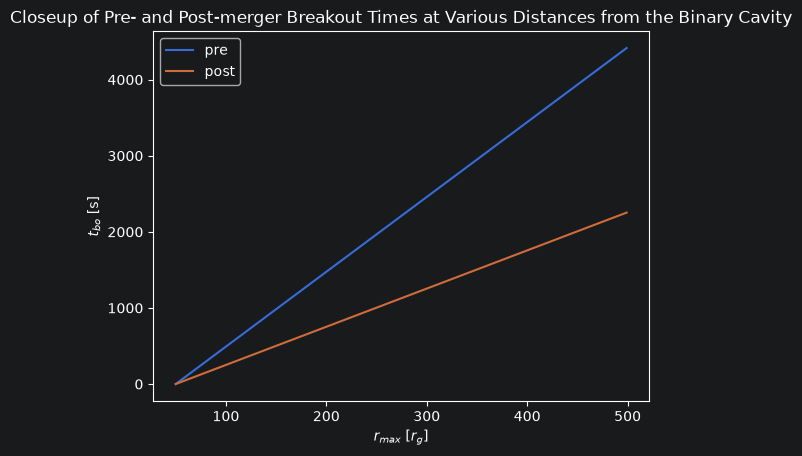

In [78]:
plt.plot(r_maxes / r_g, t_bo_pre, label='pre')
plt.plot(r_maxes / r_g, t_bo_post, label='post')
plt.xlabel(r'$r_{max}$ $[r_g]$')
plt.ylabel(r'$t_{bo}$ [s]')
# plt.xscale('log')
plt.title('Closeup of Pre- and Post-merger Breakout Times at Various Distances from the Binary Cavity')
plt.legend()
plt.show()

# Breakout luminosity

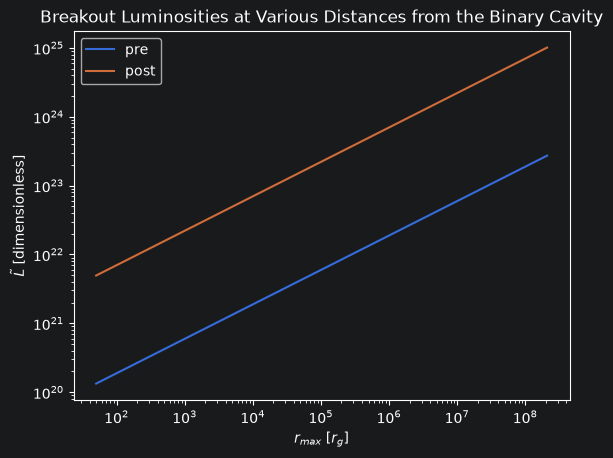

In [81]:
pre = luminosities['pre']
post = luminosities['post']
pre = dict(sorted(pre.items()))
post = dict(sorted(post.items()))
plt.plot(np.array(list(pre.keys())) / r_g, pre.values(), label='pre')
plt.plot(np.array(list(post.keys())) / r_g, post.values(), label='post')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$r_{max}$ $[r_g]$')
plt.ylabel(r'$\tilde{L}$ [dimensionless]')
plt.title('Breakout Luminosities at Various Distances from the Binary Cavity')
plt.legend()
plt.show()